<center><h1><b>LET'S FIND $D^0$ DECAYS</b></h1></center>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import awkward as ak
import uproot

from itertools import combinations
import itertools
import os
import gc

---

### PATHS OF THE DATA
These are all the paths to the data.

```python
"""
Paths:
Chunk0950                    /Chunk0950/001_007/AO2Dtree.root
Chunk1000                    [ /Chunk1000/001_005/AO2Dtree.root, /Chunk1000/006_009/AO2Dtree.root ]
Chunk1010                    [ /Chunk1010/001_005/AO2Dtree.root, /Chunk1010/006_010/AO2Dtree.root ]
Chunk1020                    /Chunk1020/001_007/AO2Dtree.root
Chunk1030                    [ /Chunk1030/001_005/AO2Dtree.root, /Chunk1030/006_011/AO2Dtree.root ]
Chunk1040                    /Chunk1040/001_007/AO2Dtree.root
Chunk1050                    [ /Chunk1050/001_005/AO2Dtree.root, /Chunk1050/006_010/AO2Dtree.root ]
Chunk1100                    [ /Chunk1100/001_005/AO2Dtree.root, /Chunk1100/006_009/AO2Dtree.root ]
Chunk1110                    /Chunk1110/001_005/AO2Dtree.root
Chunk1120                    [ /Chunk1120/001_005/AO2Dtree.root, /Chunk1120/006_011/AO2Dtree.root ]
Chunk1130                    /Chunk1130/001_008/AO2Dtree.root
Chunk1140                    [ /Chunk1140/001_006/AO2Dtree.root, /Chunk1120/007_011/AO2Dtree.root ]
Chunk1150                    /Chunk1150/001_007/AO2Dtree.root
Chunk1200                    [ /Chunk1200/001_006/AO2Dtree.root, /Chunk1120/007_011/AO2Dtree.root ]
Chunk1210                    /Chunk1210/001_008/AO2Dtree.root
Chunk1220                    /Chunk1220/001_008/AO2Dtree.root
Chunk1300                    [ /Chunk1300/001_006/AO2Dtree.root, /Chunk1300/003/AO2Dtree.root, /Chunk1300/007_010/AO2Dtree.root ]
"""
```

---

# UPLOAD PAIRS DATAFRAMES

In [10]:
base_path = "/home/bsecco"
which_chunk = "Chunk1300"
which_number = "001_006"
slices = range(0, 10)

df_list = []

for i in slices:
    
    # Generate the path:
    file_name = "pairs_" + "_".join([which_chunk, which_number, str(i)]) + ".pkl"      # Build the file name
    full_path = os.path.join(base_path, file_name)                                     # Full path to the .pkl file

    # Load and append the DataFrame
    df = pd.read_pickle(full_path)
    df_list.append(df)

# Concatenate all DataFrames
df_pairs = pd.concat(df_list, ignore_index=True)
N_pairs = len(df_pairs)

# Debug
print(f"Loaded {len(df_list)} files.")
print("The dataframe has", len(df_pairs), "rows")
memory = df_pairs.memory_usage(deep=True).sum() / (1024 ** 2)
print(f"The dataframe occupy {memory:.2f} MB")
df_pairs

Loaded 10 files.
The dataframe has 13631804 rows
The dataframe occupy 728.02 MB


,collision_index,dcaXY_product,inv_mass,pt,pz,decay_length,cos_pointing
0,1,-3.920097e-06,1.466251,2.550995,-0.295362,0.019764,-0.479430
1,1,1.705092e-06,2.598888,0.476026,-0.071934,0.028125,-0.252065
2,1,2.291358e-06,2.887628,0.438957,-0.701576,0.018993,-0.322312
3,1,-3.626041e-06,1.544647,0.916298,-0.494555,0.872318,0.856713
4,1,4.845965e-07,1.488404,1.465094,-0.829718,0.033518,-0.484306
...,...,...,...,...,...,...,...
13631799,3023779,-2.751260e-06,1.211740,0.657532,0.093203,0.017644,0.208870
13631800,3023779,1.362982e-05,0.843982,1.173171,-0.277763,0.014613,-0.447764
13631801,3023779,-4.564103e-06,2.252738,1.132577,0.459364,0.002781,-0.320721
13631802,3023779,3.190205e-05,1.013496,1.343605,-0.249762,0.026317,0.506724


---

# CUTS ON THE PAIRS

#### DECAY LENGTH
Distance between the primary vertex (PV) and the decay point, i.e. the secondary vertex (SV).  
Here we expect to observe the background with values near 0, and the signal with values not 0, near 100 $\mu m$.  

MEMO: l'unità di misura dei dati è $cm$

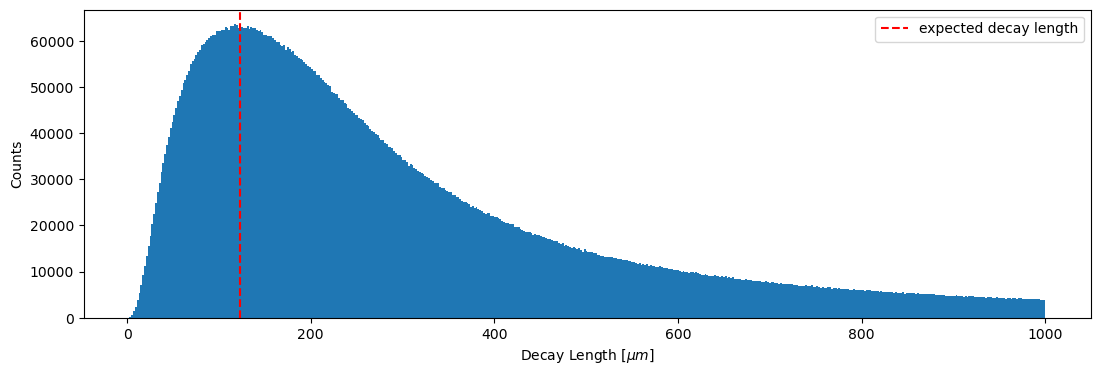

In [11]:
# ONLY PLOT CODE:
decay_len = np.array( df_pairs['decay_length'] )*10_000   # from cm to micron
# fig, ax = plt.subplots(figsize=(13,4))
# ax.hist(decay_len, bins=500)
# plt.show()

# filter for the plot:
decay_len_filt = decay_len[decay_len < 1000]
fig, ax = plt.subplots(figsize=(13,4))
ax.hist(decay_len_filt, bins=500)
ax.set_ylabel("Counts")
ax.set_xlabel(r"Decay Length [$\mu m$]")
plt.axvline(x=123, color='r', linestyle='--', label='expected decay length')
plt.legend()
plt.show()

In [12]:
# CUT CODE: let's CUT between 30 and 250 micron
N_before = len(df_pairs)      # check value

df_pairs = df_pairs[ ( (df_pairs['decay_length'] > 0.003) & (df_pairs['decay_length'] < 0.025) ) ]
N_dec = len(df_pairs)

print(f'Rejected data wrt before : {N_pairs-N_before} ----->  {(N_pairs-N_before)/N_pairs*100:.3f} %' )
print(f'Rejected data wrt start :  {N_pairs-N_dec} ----->  {(N_pairs-N_dec)/N_pairs*100:.3f} %' )
print(f'Remaining data:            {N_dec}')

Rejected data wrt before : 0 ----->  0.000 %
Rejected data wrt start :  7646224 ----->  56.091 %
Remaining data:            5985580


#### POINTING ANGLE
It's the angle between the $D_0$ momentum vector and the flight line (line between PV and SV).  
Here we expect to observe the background with values far from 0, and the signal with values nera 0 (so the momentum and the flight line aligned). Actually we work with the cosine of that angle, so we search the signal near the value 1 instead of 0.

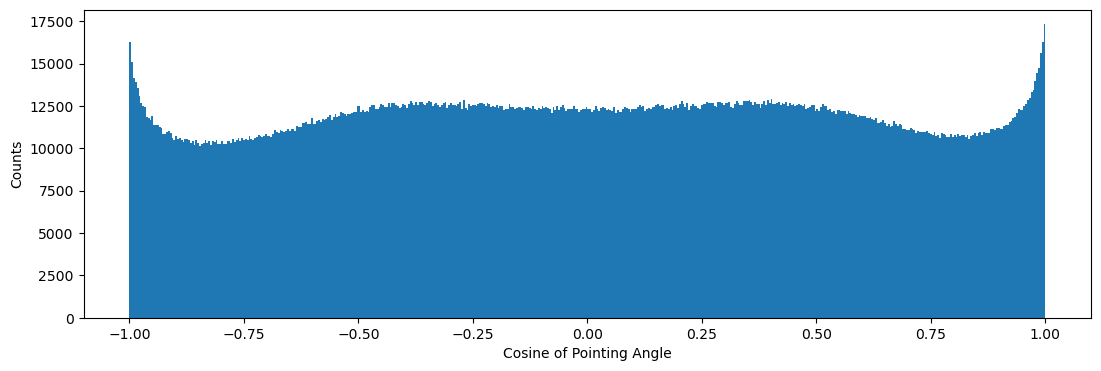

In [13]:
# ONLY PLOT CODE:
point_angle = np.array( df_pairs['cos_pointing'] )
# fig, ax = plt.subplots(figsize=(13,4))
# ax.hist(decay_len, bins=500)
# plt.show()

# filter for the plot:
point_angle_filt = point_angle[ (point_angle > -1) & (point_angle < 1)]
fig, ax = plt.subplots(figsize=(13,4))
ax.hist(point_angle_filt, bins=500)
ax.set_ylabel("Counts")
ax.set_xlabel("Cosine of Pointing Angle")
# plt.axvline(x=123, color='r', linestyle='--', label='expected')
plt.show()

In [14]:
# CUT CODE: let's CUT near value 1
N_before = len(df_pairs)      # check value

df_pairs = df_pairs[ df_pairs['cos_pointing'] > 0.50 ]   # CUT
N_point = len(df_pairs)

print(f'Rejected data wrt before : {N_pairs-N_before} ----->  {(N_pairs-N_before)/N_pairs*100:.3f} %' )
print(f'Rejected data wrt start :  {N_pairs-N_point} ----->  {(N_pairs-N_point)/N_pairs*100:.3f} %' )
print(f'Remaining data:            {N_point}')

Rejected data wrt before : 7646224 ----->  56.091 %
Rejected data wrt start :  12172404 ----->  89.294 %
Remaining data:            1459400


---

# RESULTS

#### DcaXY product PLOT

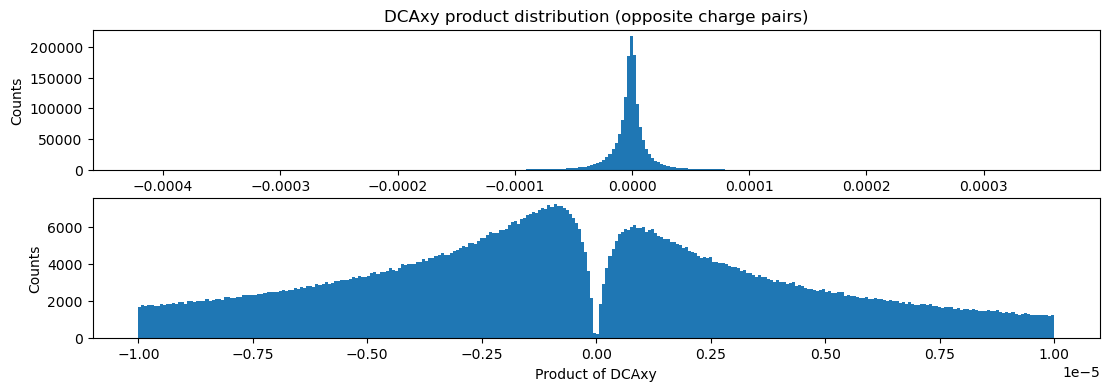

In [15]:
# Plot histogram
fig,ax = plt.subplots(2,1,figsize=(13,4))
ax[0].hist(df_pairs['dcaXY_product'], bins=300)
ax[0].set_ylabel("Counts")
ax[0].set_title("DCAxy product distribution (opposite charge pairs)")
# filter plot:
prod = df_pairs['dcaXY_product']
prod_filt = prod[ (prod>-0.00001) & (prod<0.00001) ]
ax[1].hist(prod_filt, bins=300)
ax[1].set_ylabel("Counts")
ax[1].set_xlabel("Product of DCAxy")


plt.show()

Il motivo del buco centrale è dovuto al cut iniziale sulla dcaXY, che taglia i valori vicini allo 0.

#### INAVARIANT MASS PLOT

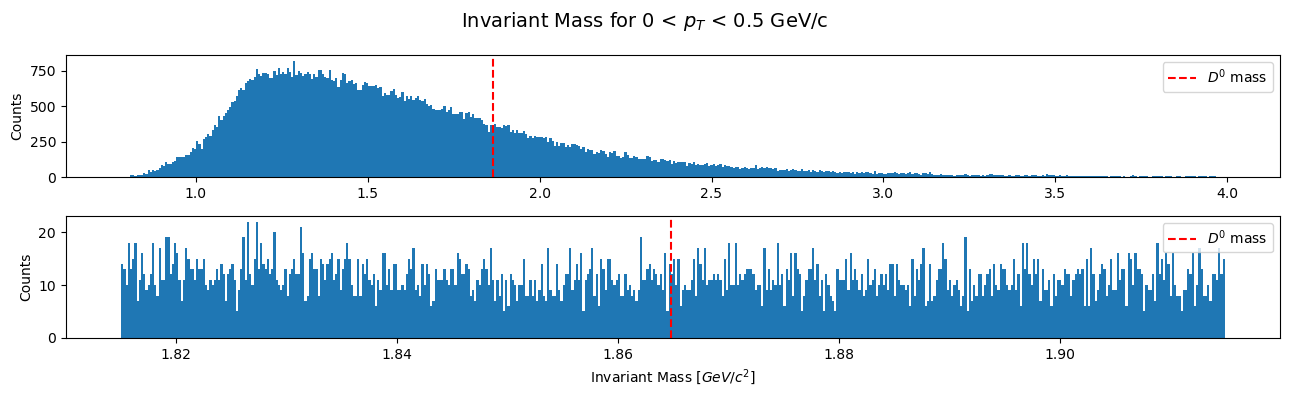

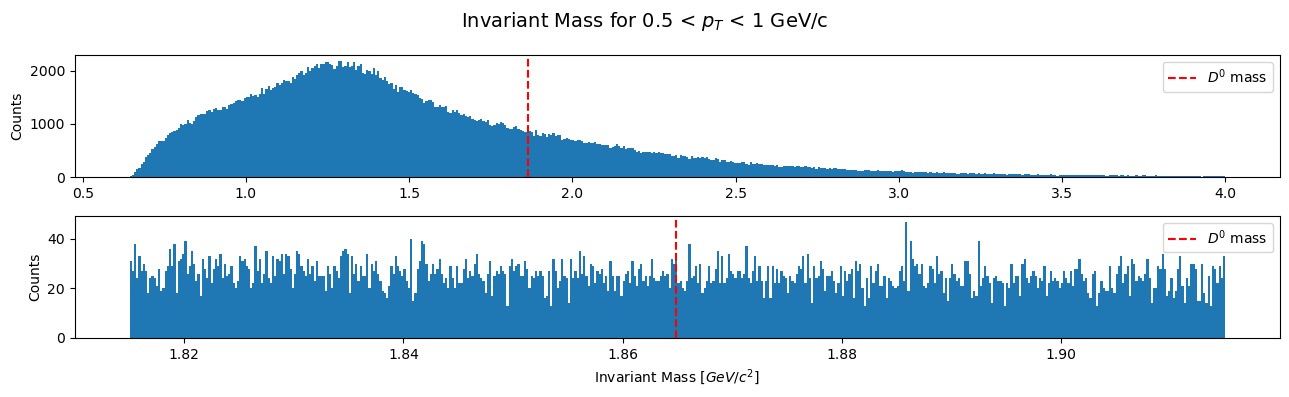

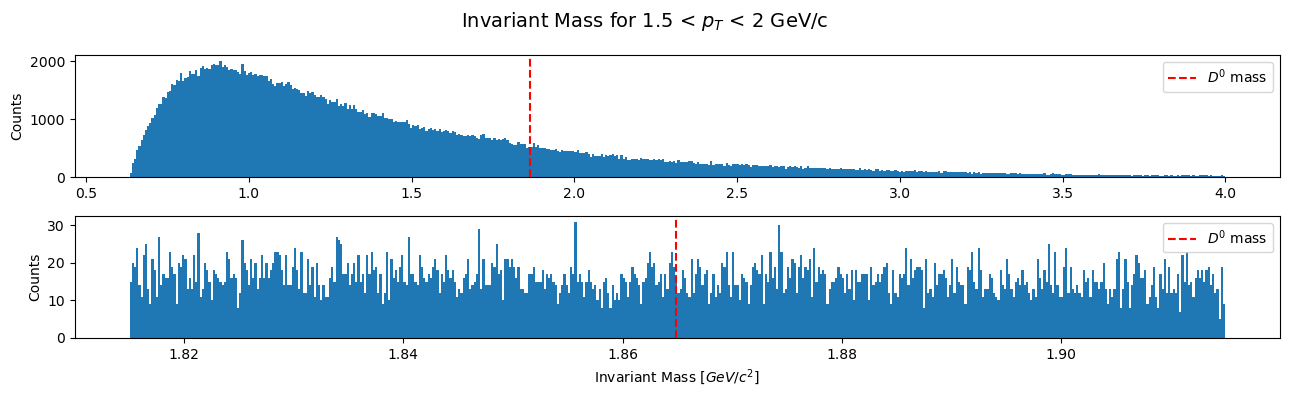

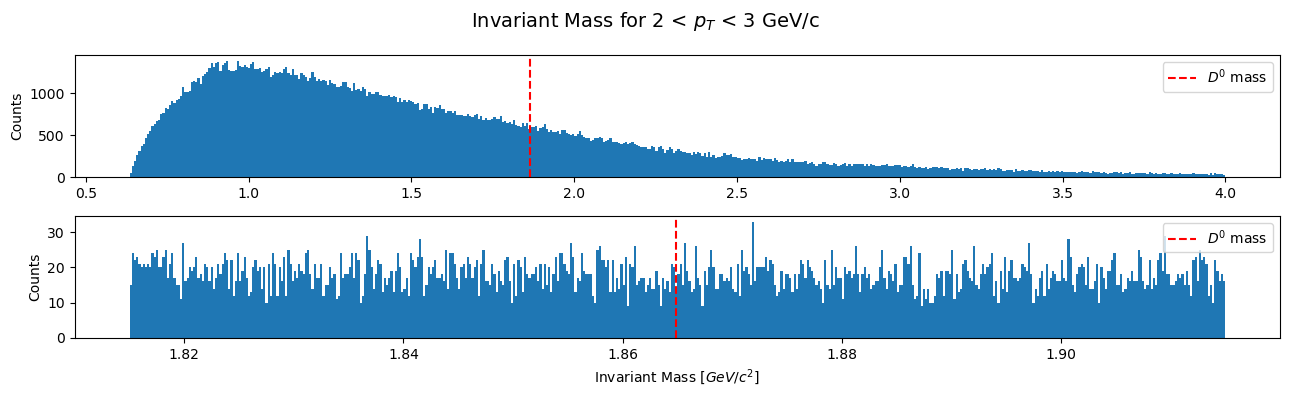

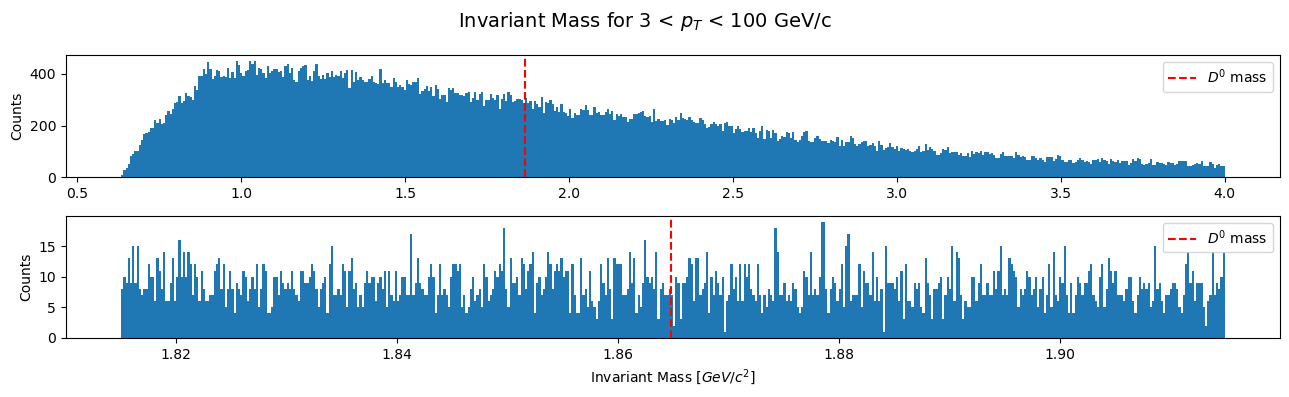

In [19]:
pt_bins = [(0, 0.5), (0.5, 1), (1.5, 2), (2, 3), (3,100)]  # define your pt slices here
# Particle masses in GeV
m_K = 0.493677
m_pi = 0.139570
m_d0 = 1.86484

for pt_min, pt_max in pt_bins:
    df_slice = df_pairs[(df_pairs['pt'] >= pt_min) & (df_pairs['pt'] < pt_max)]
    val = df_slice["inv_mass"]

    fig, ax = plt.subplots(2, 1, figsize=(13, 4))
    fig.suptitle(f"Invariant Mass for {pt_min} < $p_T$ < {pt_max} GeV/c", fontsize=14)

    # full-range plot
    ax[0].hist(val[val < 4], bins=500)
    ax[0].axvline(x=m_d0, color='red', linestyle='--', linewidth=1.5, label='$D^0$ mass')
    ax[0].legend()
    ax[0].set_ylabel("Counts")

    # zoom-in plot
    zoom_val = val[(val > 1.815) & (val < 1.915)]
    ax[1].hist(zoom_val, bins=500)
    ax[1].axvline(x=m_d0, color='red', linestyle='--', linewidth=1.5, label='$D^0$ mass')
    ax[1].legend()
    ax[1].set_xlabel("Invariant Mass [$GeV/c^2$]")
    ax[1].set_ylabel("Counts")

    plt.tight_layout()
    plt.show()


---

In [3]:
# # CODE FOR MONITORING RAM LIVE USAGE:
# # run it in a different notebook from the one you are using
# import psutil
# import time
# from IPython.display import clear_output

# for _ in range(100):
#     mem = psutil.virtual_memory()
#     clear_output(wait=True)
#     print(f"Used: {mem.used / 1e9:.2f} GB | Available: {mem.available / 1e9:.2f} GB")
#     time.sleep(1)


Used: 1.06 GB | Available: 2.77 GB
